## Ensemble Approach

In [35]:
!pip install numpy
!pip install matplotlib
!pip install scipy
!pip install scikit-learn
!pip install pandas
!pip install seaborn
!pip install tensorflow
!pip install torch
!pip install xgboost
!pip install torchvision
!pip install opencv-python


143420.95s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


143426.63s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


143432.34s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


143438.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


143443.62s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


...

143460.37s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


143466.18s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


143471.87s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


143477.47s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)


In [42]:
#Section 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import models
from sklearn.metrics import accuracy_score

In [16]:
#Section 2 - Device Configuration

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using device: cpu
Using Apple GPU (MPS)


In [17]:
#Section 3 - Inmage Transformations 

#This section is for preprocessing all images before training so it resize all images to same size, normalizes the pixel values to be between 0
#and convert images from pixels.

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [18]:
#Section 4 - Custom Dataset Class

#This willl load images from folders.

class LeaDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        label = self.labels[idx]
        
        # Apply transformations if any
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [26]:
#Section 5 - Load Dataset Paths and Labels

#This section collects all image paths and labels and label mapping will be 0 - Non Stress and 1 - Streess.
#
# 1. Tomato Dataset
# 2. Maize Folder Dataset
# 3. Maize .npy Dataset
#
# Tomato Dataset Mapping
#
# 100%_field_capacity → Non-stress (0)
# 75%_field_capacity  → Stress (1)
# 50%_field_capacity  → Stress (1)
# 25%_field_capacity  → Stress (1)

def load_tomato_dataset(dataset_path):
    image_paths = []
    labels = []

    stress_folders = [
        "25%_field_capacity",
        "50%_field_capacity",
        "75%_field_capacity"
    ]

    non_stress_folders = [
        "100%_field_capacity"
    ]

    for folder in os.listdir(dataset_path):
        if folder.startswith("."):
            continue
        folder_path = os.path.join(dataset_path, folder)

        # Skip if not directory
        if not os.path.isdir(folder_path):
            continue

        #Assign Labels
        if folder in stress_folders:
            label = 1  # Stress
        else:
            label = 0  # Non-stress

        for img_file in os.listdir(folder_path):
            if img_file.startswith("."):
                continue

            img_path = os.path.join(folder_path, img_file)
            image_paths.append(img_path)
            labels.append(label)
            
    return image_paths, labels
 

In [27]:
# Maize Folder Dataset Mapping
#
# WW  → Non-stress (0)
# MIS → Stress (1)
# MOD → Stress (1)
# WS  → Stress (1)

def load_maize_dataset(dataset_path):

    image_paths = []
    labels = []

    stress_folders = ["MIS", "MOD", "WS"]
    non_stress_folders = ["WW"]

    for folder in os.listdir(dataset_path):

        if folder.startswith("."):
            continue

        folder_path = os.path.join(dataset_path, folder)

        if not os.path.isdir(folder_path):
            continue

        # Assign labels
        if folder in stress_folders:
            label = 1
        else:
            label = 0

        for img_file in os.listdir(folder_path):

            if img_file.startswith("."):
                continue

            img_path = os.path.join(folder_path, img_file)

            image_paths.append(img_path)
            labels.append(label)

    return image_paths, labels

In [21]:
#Load .npy maize dataset

#In this the important task is to check the format of lables for example 0 and 1 or labels are multicalss if that they need to be converted to binary labels.

npy_dataset_path = "/Users/manish/Documents/Semister 2/7. Project/Dataset/MaizeLeaf_dataset"

# Load arrays
train_maize2_data = np.load(os.path.join(npy_dataset_path, "trainData.npy"))
train_maize2_labels = np.load(os.path.join(npy_dataset_path, "trainLabel.npy"))

val_maize2_data = np.load(os.path.join(npy_dataset_path, "valData.npy"))
val_maize2_labels = np.load(os.path.join(npy_dataset_path, "valLabel.npy"))

test_maize2_data = np.load(os.path.join(npy_dataset_path, "testData.npy"))
test_maize2_labels = np.load(os.path.join(npy_dataset_path, "testLabel.npy"))

print("Train Shape:", train_maize2_data.shape)
print("Validation Shape:", val_maize2_data.shape)
print("Test Shape:", test_maize2_data.shape)

print("Unique Labels:", np.unique(train_maize2_labels))


Train Shape: (9580, 48, 48, 3)
Validation Shape: (2395, 48, 48, 3)
Test Shape: (6065, 48, 48, 3)
Unique Labels: [0 1 2]


In [23]:
# Original Labels:
# 0 - Well-watered
# 1 - Reduced-watered
# 2 - Drought-stressed
#
# New Labels:
# 0 - Non-stress
# 1 - Stress

train_maize2_labels = np.where(train_maize2_labels == 0, 0, 1)

val_maize2_labels = np.where(val_maize2_labels == 0, 0, 1)

test_maize2_labels = np.where(test_maize2_labels == 0, 0, 1)

# Check converted labels
print("Converted Train Labels:", np.unique(train_maize2_labels))
print("Converted Validation Labels:", np.unique(val_maize2_labels))
print("Converted Test Labels:", np.unique(test_maize2_labels))

Converted Train Labels: [0 1]
Converted Validation Labels: [0 1]
Converted Test Labels: [0 1]


In [24]:
# Check class distribution

print("Train Label Distribution:")
print(np.bincount(train_maize2_labels))

print("Validation Label Distribution:")
print(np.bincount(val_maize2_labels))

print("Test Label Distribution:")
print(np.bincount(test_maize2_labels))

Train Label Distribution:
[3200 6380]
Validation Label Distribution:
[ 875 1520]
Test Label Distribution:
[2245 3820]


In [28]:
#Section 7 - Load all datasets

tomato_image_path = "/Users/manish/Documents/Semister 2/7. Project/Dataset/Tomato Plant dataset/dataset"
maize_image_path = "/Users/manish/Documents/Semister 2/7. Project/Dataset/Maize Water Stress"

# Load Tomato Dataset
tomato_images, tomato_labels = load_tomato_dataset(tomato_image_path)

# Load Maize Dataset
maize_images, maize_labels = load_maize_dataset(maize_image_path)

print("Tomato Images:", len(tomato_images))
print("Maize Images:", len(maize_images))

print("Tomato Labels:", np.unique(tomato_labels))
print("Maize Labels:", np.unique(maize_labels))

Tomato Images: 20955
Maize Images: 400
Tomato Labels: [0 1]
Maize Labels: [0 1]


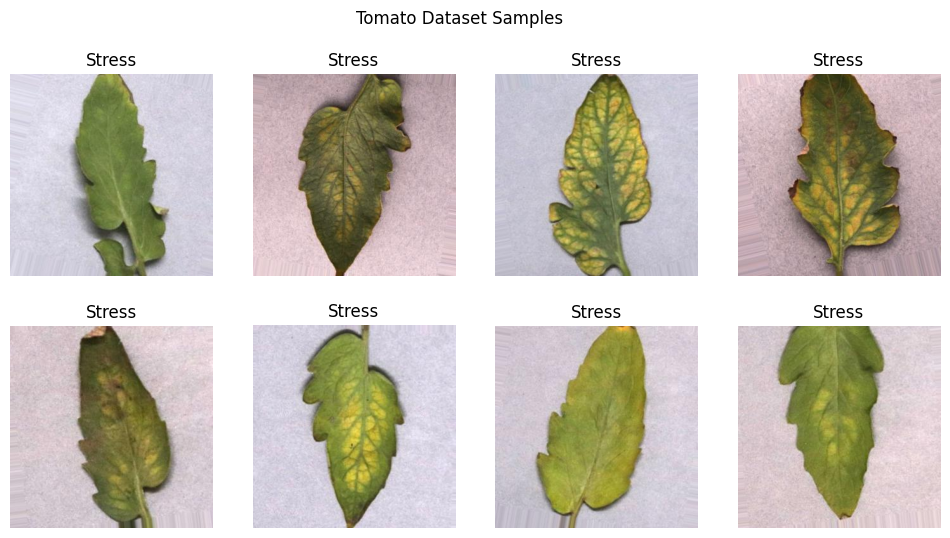

In [56]:
#Section 8 - View sample Images
label_names = {
    0: "Non-stress",
    1: "Stress"
}

random_indices = random.sample(range(len(tomato_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(tomato_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = tomato_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Tomato Dataset Samples")
plt.show()

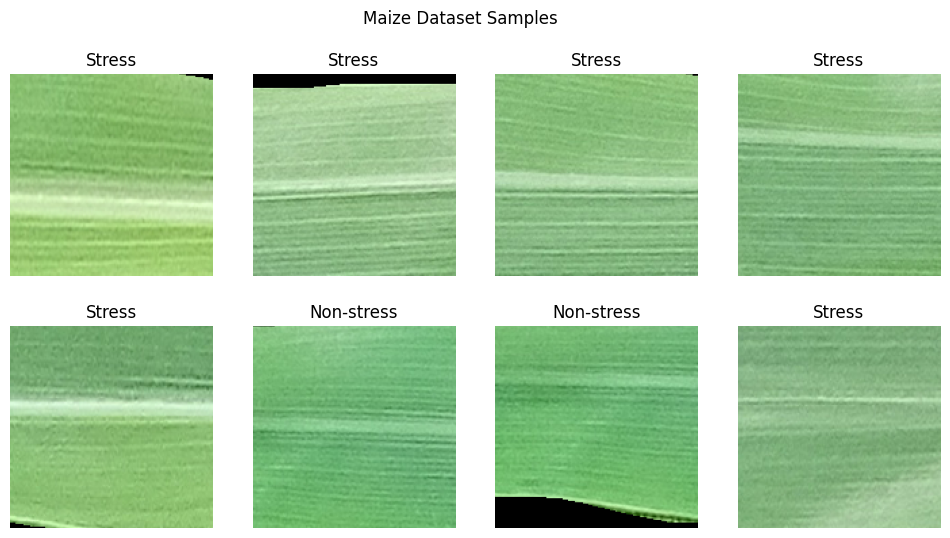

In [57]:
random_indices = random.sample(range(len(maize_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(maize_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = maize_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Maize Dataset Samples")
plt.show()

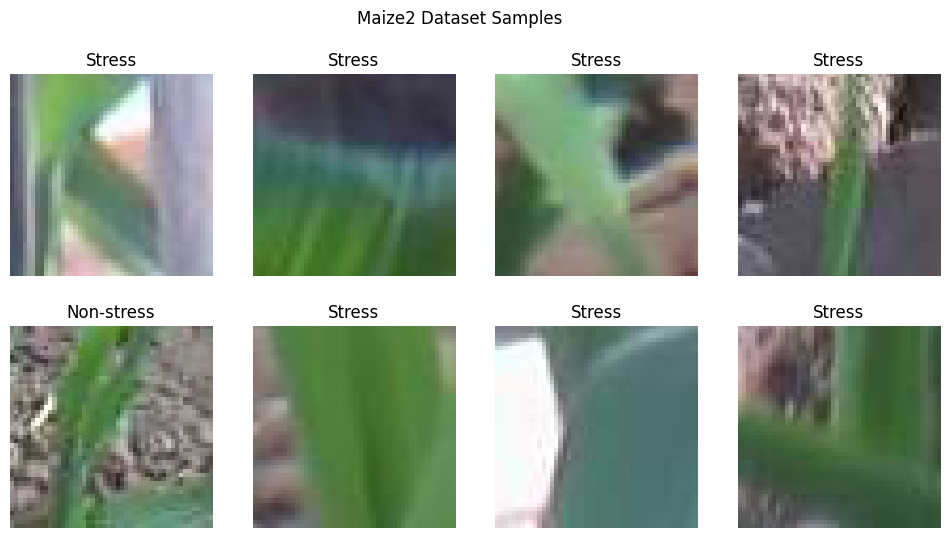

In [58]:
# Random sample indices
random_indices = random.sample(range(len(train_maize2_data)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    # Directly get image array
    image = train_maize2_data[idx]

    # Get label
    label = train_maize2_labels[idx]

    plt.subplot(2,4,i+1)

    # Display image
    plt.imshow(image.astype("uint8"))

    plt.title(label_names[label])

    plt.axis("off")

plt.suptitle("Maize2 Dataset Samples")

plt.show()